# GPT-2 (124M) Pre-Training from Scratch (AI Generated)

**AI Workshop — Training a Language Model from Scratch on a Single H100**

This notebook trains a 124M-parameter transformer language model from scratch
on the FineWeb-Edu dataset.

**First run: 100M tokens** (~3-5 min) to verify everything works.
Then set `MAX_TOKENS = 10_000_000_000` for the full reproduction (~5-6 hours).

Every architecture decision (AD#) and hyperparameter (HP#) is annotated inline.

In [ ]:
!pip install -q tiktoken datasets

In [ ]:
import os, math, time, json
import tiktoken
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from datasets import load_dataset

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Memory: 102.0 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CKPT_DIR = "/content/drive/MyDrive/gpt2_workshop/checkpoints"
LOG_DIR  = "/content/drive/MyDrive/gpt2_workshop/logs"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
print(f"Checkpoints: {CKPT_DIR}")

Mounted at /content/drive
Checkpoints: /content/drive/MyDrive/gpt2_workshop/checkpoints


## Model Configuration

All architecture decisions and hyperparameters from the workshop tables.

In [ ]:
@dataclass
class GPTConfig:
    # ---- Architecture Decisions ----
    # AD#1:  Activation          = ReLU squared
    # AD#2:  Initialization      = He / Kaiming
    # AD#3:  FFN                 = Standard 2-projection MLP
    # AD#4:  Normalization       = Pre-norm RMSNorm
    # AD#5:  Output function     = SoftMax (inside cross-entropy)
    # AD#6:  Positional embed    = RoPE
    # AD#7:  Attention           = Causal self-attention, MHA
    # AD#8:  Tokenizer           = BPE (tiktoken gpt-2)
    # AD#9:  Embed/unembed       = Tied (transpose)
    # AD#10: Residual            = Sum pre + post
    # AD#11: Dropout             = After linear layers
    # AD#12: Data type           = bfloat16 (applied in training loop)

    n_layer:    int   = 12     # HP#4: Number of layers
    n_head:     int   = 12     # HP#3: Attention heads (64 dims/head)
    n_embd:     int   = 768    # HP#1: Hidden dimension
    vocab_size: int   = 50304  # HP#5: Padded from 50257 (Runtime Opt #5)
    block_size: int   = 1024   # HP#6: Context length
    dropout:    float = 0.1    # HP#7: Dropout rate
    n_inner:    int   = 3072   # HP#2: FFN intermediate (4 * d_model)
    rope_theta: float = 10000.0


@dataclass
class TrainConfig:
    max_lr:            float = 6e-4       # HP#8:  Peak learning rate
    min_lr:            float = 6e-5       # HP#9:  Min LR (10% of peak)
    warmup_steps:      int   = 2000       # HP#10: Warmup steps
    weight_decay:      float = 0.1        # HP#11: Weight decay (2D tensors only)
    total_batch_tokens:int   = 524288     # HP#12: ~0.5M tokens per gradient step
    micro_batch_size:  int   = 16         # HP#13: Sequences per forward pass
    max_tokens:        int   = 10_000_000_000 # 100_000_000  # HP#15: 100M for first run
    save_every:        int   = 100        # Checkpoint frequency (steps)
    eval_every:        int   = 200        # eval frequency (steps)
    # AD#14: Optimizer = AdamW
    # AD#15: LR schedule = Cosine decay with linear warmup
    # AD#16: Loss function = Cross-entropy


model_config = GPTConfig()
train_config = TrainConfig()

SEQ_LEN = model_config.block_size
GRAD_ACCUM_STEPS = train_config.total_batch_tokens // (train_config.micro_batch_size * SEQ_LEN)
print(f"Grad accum steps: {GRAD_ACCUM_STEPS}")
print(f"Tokens/step: {GRAD_ACCUM_STEPS * train_config.micro_batch_size * SEQ_LEN:,}")
print(f"Total tokens: {train_config.max_tokens:,}")

Grad accum steps: 32
Tokens/step: 524,288
Total tokens: 10,000,000,000


## Model Architecture

1. **RMSNorm** (AD#4) — no mean subtraction, faster than LayerNorm
2. **RoPE** (AD#6) — rotary position encoding baked into Q and K
3. **CausalSelfAttention** (AD#7) — MHA with Flash Attention via SDPA
4. **MLP** (AD#1, AD#3) — two projections with ReLU² activation
5. **TransformerBlock** (AD#4, AD#10) — pre-norm with residual connections
6. **GPT** (AD#9) — stacked blocks with tied embeddings

In [ ]:
# ================================================================
# AD#4: Pre-norm RMSNorm
# Normalizes by root-mean-square without subtracting the mean.
# Skips the mean() op => fewer FLOPs than LayerNorm.
# ================================================================
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return x * rms * self.weight


# ================================================================
# AD#6: Rotary Positional Embeddings (RoPE)
# Encodes position by rotating pairs of dimensions in Q and K.
# Position info is relative, not absolute — better generalization.
# ================================================================
def precompute_rope(head_dim, max_seq_len, theta=10000.0):
    # Frequency for each pair of dimensions
    freqs = 1.0 / (theta ** (torch.arange(0, head_dim, 2).float() / head_dim))
    # Position indices
    t = torch.arange(max_seq_len).float()
    # Outer product => (max_seq_len, head_dim // 2)
    angles = torch.outer(t, freqs)
    return angles.cos(), angles.sin()


def apply_rope(x, cos, sin):
    # x: (B, n_head, T, head_dim)
    # cos, sin: (1, 1, T, head_dim//2) — broadcasts over batch & heads
    d = x.shape[-1] // 2
    x1, x2 = x[..., :d], x[..., d:]
    return torch.cat([x1 * cos - x2 * sin,
                      x1 * sin + x2 * cos], dim=-1)

In [ ]:
# ================================================================
# AD#7: Causal Self-Attention with MHA
# HP#3: 12 heads, 64 dims per head
# Runtime Optimization #4: Flash Attention via F.scaled_dot_product_attention
# ================================================================
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head = config.n_head
        self.head_dim = config.n_embd // config.n_head
        self.dropout_p = config.dropout

        # Separate Q, K, V projections — no bias (modern practice)
        self.q_proj   = nn.Linear(config.n_embd, config.n_embd, bias=False)
        self.k_proj   = nn.Linear(config.n_embd, config.n_embd, bias=False)
        self.v_proj   = nn.Linear(config.n_embd, config.n_embd, bias=False)
        self.out_proj = nn.Linear(config.n_embd, config.n_embd, bias=False)
        self.out_proj._is_residual = True  # flag for scaled init
        self.resid_dropout = nn.Dropout(config.dropout)

    def forward(self, x, rope_cos, rope_sin):
        B, T, C = x.shape

        # Project and reshape to (B, n_head, T, head_dim)
        q = self.q_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        # AD#6: Apply RoPE to queries and keys
        q = apply_rope(q, rope_cos, rope_sin)
        k = apply_rope(k, rope_cos, rope_sin)

        # Runtime Opt #4: Flash Attention via SDPA
        # Uses FlashAttention-2 on H100, never materializes N*N matrix.
        y = F.scaled_dot_product_attention(
            q, k, v, is_causal=True,
            dropout_p=self.dropout_p if self.training else 0.0,
        )

        # (B, n_head, T, head_dim) -> (B, T, C)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.out_proj(y))

In [ ]:
# ================================================================
# AD#1: Activation = ReLU squared
# AD#3: Standard 2-projection MLP (no gate — simpler than SwiGLU)
# HP#2: Intermediate size = 3072 (4 * d_model)
#
# ReLU^2 = relu(x)**2. Simpler and empirically faster to train
# at this scale (modded-nanogpt finding). Two projections vs three.
# ================================================================
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.fc_in  = nn.Linear(config.n_embd, config.n_inner, bias=False)
        self.fc_out = nn.Linear(config.n_inner, config.n_embd, bias=False)
        self.fc_out._is_residual = True
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.fc_in(x)
        x = F.relu(x).square()   # AD#1: ReLU^2
        x = self.fc_out(x)
        return self.dropout(x)

In [ ]:
# ================================================================
# AD#4:  Pre-norm (RMSNorm before attention and MLP)
# AD#10: Residual connections (sum input + sublayer output)
# ================================================================
class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = RMSNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = RMSNorm(config.n_embd)
        self.mlp  = MLP(config)

    def forward(self, x, rope_cos, rope_sin):
        x = x + self.attn(self.ln_1(x), rope_cos, rope_sin)   # AD#10
        x = x + self.mlp(self.ln_2(x))                         # AD#10
        return x

In [ ]:
# ================================================================
# Full GPT model
# AD#9:  Tied embeddings (lm_head.weight = wte.weight)
# AD#2:  He/Kaiming initialization (pairs with ReLU^2)
# Logit soft-capping (Runtime Opt #8) for training stability
# ================================================================
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h    = nn.ModuleList([TransformerBlock(config)
                                  for _ in range(config.n_layer)]),
            ln_f = RMSNorm(config.n_embd),
        ))

        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        # AD#9: Tied embeddings — unembedding = transpose of embedding
        self.lm_head.weight = self.transformer.wte.weight

        # AD#6: Precompute RoPE tables
        head_dim = config.n_embd // config.n_head
        cos, sin = precompute_rope(head_dim, config.block_size, config.rope_theta)
        self.register_buffer("rope_cos", cos)
        self.register_buffer("rope_sin", sin)

        # AD#2: He/Kaiming init
        self.apply(self._init_weights)
        # Scale residual projections for stability
        for m in self.modules():
            if getattr(m, '_is_residual', False):
                with torch.no_grad():
                    m.weight *= (2 * config.n_layer) ** -0.5

    def _init_weights(self, module):
        # AD#2: He/Kaiming normal — pairs with ReLU^2 activation
        if isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        x = self.transformer.drop(self.transformer.wte(idx))

        # RoPE: (1, 1, T, head_dim//2) for broadcasting
        cos = self.rope_cos[:T].unsqueeze(0).unsqueeze(0)
        sin = self.rope_sin[:T].unsqueeze(0).unsqueeze(0)

        for block in self.transformer.h:
            x = block(x, cos, sin)

        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)

        # Runtime Opt #8: Logit soft-capping for stability at high LR
        logits = 30.0 * torch.tanh(logits / 30.0)

        loss = None
        if targets is not None:
            # AD#16: Cross-entropy loss (AD#5: softmax is inside CE)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                   targets.view(-1))
        return logits, loss


# Build model
model = GPT(model_config).cuda()
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")
print(f"  (Unique, excl. tied: {n_params - model.lm_head.weight.numel():,})")

Parameters: 123,587,328
  (Unique, excl. tied: 84,953,856)


## Dataset

**AD#17: FineWeb-Edu** (sample-10BT) — high-quality educational web content.
**AD#8: BPE tokenizer** via tiktoken (GPT-2 encoding, 50257 tokens).

We stream from HuggingFace and tokenize on the fly.
Documents are separated by `<|endoftext|>`.

In [ ]:
# AD#8: BPE Tokenizer
enc = tiktoken.get_encoding("gpt2")
EOT = enc.eot_token  # <|endoftext|> = 50256


class FineWebStreamer:
    # AD#17: FineWeb-Edu pretraining data
    def __init__(self, batch_size, seq_len, split="train"):
        self.batch_size = batch_size
        self.seq_len = seq_len
        self.needed = batch_size * seq_len + 1

        self.dataset = load_dataset(
            "HuggingFaceFW/fineweb-edu",
            name="sample-100BT",
            split=split,
            streaming=True,
        )
        self.iterator = iter(self.dataset)
        self.buffer = []
        self.tokens_served = 0
        self.docs = 0

    def _fill(self):
        while len(self.buffer) < self.needed:
            try:
                doc = next(self.iterator)
            except StopIteration:
                print("Dataset exhausted — restarting")
                self.iterator = iter(self.dataset)
                doc = next(self.iterator)
            tokens = enc.encode_ordinary(doc["text"])
            tokens.append(EOT)
            self.buffer.extend(tokens)
            self.docs += 1

    def get_batch(self):
        self._fill()
        chunk = torch.tensor(self.buffer[:self.needed], dtype=torch.long)
        self.buffer = self.buffer[self.needed:]

        x = chunk[:-1].view(self.batch_size, self.seq_len)
        y = chunk[1:].view(self.batch_size, self.seq_len)
        self.tokens_served += self.batch_size * self.seq_len
        return x.cuda(), y.cuda()


train_data = FineWebStreamer(train_config.micro_batch_size, SEQ_LEN)
print(f"Ready: {train_config.micro_batch_size} x {SEQ_LEN} = "
      f"{train_config.micro_batch_size * SEQ_LEN:,} tokens/microbatch")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/140 [00:00<?, ?it/s]

Ready: 16 x 1024 = 16,384 tokens/microbatch


## Training Setup

**Runtime optimizations** (cumulative ~11x on H100):
1. TF32 precision (~3x)
2. BFloat16 autocast (~10%)
3. torch.compile (~2.3x)
4. Flash Attention via SDPA (~26%) — built into attention
5. Vocab padding to 50304 (~25%) — already in config
6. Fused AdamW (~3%)

In [ ]:
# Runtime Opt #1: TF32 — uses Tensor Cores, ~3x matmul speedup
torch.set_float32_matmul_precision("high")

# Runtime Opt #3: torch.compile — fuses ops, ~2.3x speedup
print("Compiling model (~40s)...")
model = torch.compile(model)
print("Done.")


# AD#15: Cosine decay with linear warmup
def get_lr(step):
    total_steps = train_config.max_tokens // train_config.total_batch_tokens
    if step < train_config.warmup_steps:
        return train_config.max_lr * (step / train_config.warmup_steps)
    if step >= total_steps:
        return train_config.min_lr
    decay = (step - train_config.warmup_steps) / (total_steps - train_config.warmup_steps)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay))
    return train_config.min_lr + coeff * (train_config.max_lr - train_config.min_lr)


# AD#14: AdamW — weight decay on 2D params only
def make_optimizer(model):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (decay if p.dim() >= 2 else no_decay).append(p)

    groups = [
        {"params": decay,    "weight_decay": train_config.weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]
    # Runtime Opt #6: fused=True => single CUDA kernel
    opt = torch.optim.AdamW(groups, lr=train_config.max_lr,
                            betas=(0.9, 0.95), fused=True)
    print(f"Decay: {sum(p.numel() for p in decay):,} params")
    print(f"No-decay: {sum(p.numel() for p in no_decay):,} params")
    return opt

optimizer = make_optimizer(model)

Compiling model (~40s)...
Done.
Decay: 123,568,128 params
No-decay: 19,200 params


In [ ]:
# ================================================================
# Checkpointing to Google Drive
# AD#13: Weight format = .pth
# ================================================================
def save_ckpt(model, optimizer, step, tokens, losses, path=None):
    if path is None:
        path = os.path.join(CKPT_DIR, f"step_{step:06d}.pth")
    state = model._orig_mod.state_dict() if hasattr(model, '_orig_mod') else model.state_dict()
    torch.save({
        "model": state,
        "optimizer": optimizer.state_dict(),
        "step": step,
        "tokens": tokens,
        "losses": losses,
        "model_config": model_config.__dict__,
        "train_config": train_config.__dict__,
    }, os.path.join(CKPT_DIR, "latest.pth"))
    # }, path)
    # Also save as latest for easy resume
    #torch.save(torch.load(path, weights_only=False),
    #           os.path.join(CKPT_DIR, "latest.pth"))
    print(f"  [SAVED] step {step}, {tokens:,} tokens")


def load_ckpt():
    path = os.path.join(CKPT_DIR, "latest.pth")
    if not os.path.exists(path):
        print("No checkpoint found — starting fresh.")
        return None
    ckpt = torch.load(path, map_location="cuda", weights_only=False)
    print(f"Resuming from step {ckpt['step']}, {ckpt['tokens']:,} tokens")
    return ckpt


def restore(model, optimizer, ckpt):
    if ckpt is None:
        return 0, 0, []
    target = model._orig_mod if hasattr(model, '_orig_mod') else model
    target.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    return ckpt["step"], ckpt["tokens"], ckpt["losses"]


# Restore if checkpoint exists
ckpt = load_ckpt()
start_step, tokens_seen, loss_history = restore(model, optimizer, ckpt)

# Fast-forward data streamer if resuming
if tokens_seen > 0:
    approx_docs = tokens_seen // 500
    train_data.dataset = train_data.dataset.skip(approx_docs)
    train_data.iterator = iter(train_data.dataset)
    train_data.tokens_served = tokens_seen
    print(f"Skipped ~{approx_docs:,} docs, resumed at {tokens_seen:,} tokens")

Resuming from step 9900, 5,290,065,920 tokens
Skipped ~10,580,131 docs, resumed at 5,290,065,920 tokens


## Training Loop

- Gradient accumulation to ~0.5M tokens/step
- **Runtime Opt #2**: BFloat16 autocast (AD#12)
- Gradient norm clipping at 1.0
- Periodic checkpoints to Google Drive

In [ ]:
total_steps = train_config.max_tokens // train_config.total_batch_tokens
print(f"Training: {total_steps:,} steps ({train_config.max_tokens:,} tokens)")
print(f"Grad accum: {GRAD_ACCUM_STEPS} micro-steps/step")
print("-" * 70)

model.train()
t0 = time.time()

for step in range(start_step, total_steps):
    step_t0 = time.time()

    # AD#15: Cosine LR schedule
    lr = get_lr(step)
    for pg in optimizer.param_groups:
        pg["lr"] = lr

    optimizer.zero_grad()
    accum_loss = 0.0

    for micro in range(GRAD_ACCUM_STEPS):
        x, y = train_data.get_batch()

        # Runtime Opt #2: BFloat16 mixed precision (AD#12)
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            _, loss = model(x, y)

        (loss / GRAD_ACCUM_STEPS).backward()
        accum_loss += loss.item()

    avg_loss = accum_loss / GRAD_ACCUM_STEPS
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    tokens_seen += train_config.total_batch_tokens
    torch.cuda.synchronize()
    dt = time.time() - step_t0
    tps = train_config.total_batch_tokens / dt

    loss_history.append({"step": step, "loss": avg_loss, "lr": lr,
                         "tokens": tokens_seen})

    if step % 10 == 0 or step == total_steps - 1:
        pct = tokens_seen / train_config.max_tokens * 100
        print(f"step {step:>6d}/{total_steps} | loss {avg_loss:.4f} | "
              f"lr {lr:.2e} | gnorm {grad_norm:.2f} | "
              f"{tps:,.0f} tok/s | {pct:.1f}%")

    if (step + 1) % train_config.save_every == 0 or step == total_steps - 1:
        save_ckpt(model, optimizer, step + 1, tokens_seen, loss_history)

    if tokens_seen >= train_config.max_tokens:
        print(f"\nReached {train_config.max_tokens:,} tokens. Done.")
        save_ckpt(model, optimizer, step + 1, tokens_seen, loss_history)
        break

total_time = time.time() - t0
print(f"\nTime: {total_time:.1f}s ({total_time/3600:.2f}h)")

with open(os.path.join(LOG_DIR, "loss_history.json"), "w") as f:
    json.dump(loss_history, f)

Training: 19,073 steps (10,000,000,000 tokens)
Grad accum: 32 micro-steps/step
----------------------------------------------------------------------
step   9900/19073 | loss 3.2778 | lr 3.62e-04 | gnorm 0.19 | 568 tok/s | 52.9%
step   9910/19073 | loss 3.2962 | lr 3.61e-04 | gnorm 0.18 | 222,009 tok/s | 53.0%
step   9920/19073 | loss 3.2770 | lr 3.61e-04 | gnorm 0.17 | 221,142 tok/s | 53.0%
step   9930/19073 | loss 3.2908 | lr 3.60e-04 | gnorm 0.19 | 223,404 tok/s | 53.1%
step   9940/19073 | loss 3.1970 | lr 3.60e-04 | gnorm 0.17 | 221,681 tok/s | 53.1%
step   9950/19073 | loss 3.1967 | lr 3.59e-04 | gnorm 0.20 | 223,093 tok/s | 53.2%
step   9960/19073 | loss 3.1881 | lr 3.59e-04 | gnorm 0.21 | 221,528 tok/s | 53.2%
step   9970/19073 | loss 3.2179 | lr 3.58e-04 | gnorm 0.19 | 222,650 tok/s | 53.3%
step   9980/19073 | loss 3.1767 | lr 3.58e-04 | gnorm 0.17 | 222,630 tok/s | 53.3%
step   9990/19073 | loss 3.2210 | lr 3.57e-04 | gnorm 0.20 | 221,267 tok/s | 53.4%
  [SAVED] step 10000, 5,

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu/resolve/87f09149ef4734204d70ed1d046ddc9ca3f2b8f9/sample/100BT/001_00009.parquet
Retrying in 1s [Retry 1/5].


step  16330/19073 | loss 3.2264 | lr 9.37e-05 | gnorm 0.16 | 219,707 tok/s | 86.6%
step  16340/19073 | loss 3.1611 | lr 9.34e-05 | gnorm 0.16 | 220,903 tok/s | 86.7%
step  16350/19073 | loss 3.2021 | lr 9.32e-05 | gnorm 0.18 | 220,503 tok/s | 86.7%
step  16360/19073 | loss 3.2565 | lr 9.30e-05 | gnorm 0.17 | 221,763 tok/s | 86.8%
step  16370/19073 | loss 3.2270 | lr 9.27e-05 | gnorm 0.18 | 221,416 tok/s | 86.8%
step  16380/19073 | loss 3.2000 | lr 9.25e-05 | gnorm 0.17 | 221,625 tok/s | 86.9%
step  16390/19073 | loss 3.1858 | lr 9.22e-05 | gnorm 0.18 | 220,159 tok/s | 86.9%
  [SAVED] step 16400, 8,697,937,920 tokens
step  16400/19073 | loss 3.2378 | lr 9.20e-05 | gnorm 0.19 | 219,160 tok/s | 87.0%
step  16410/19073 | loss 3.2010 | lr 9.18e-05 | gnorm 0.18 | 220,323 tok/s | 87.0%
step  16420/19073 | loss 3.2005 | lr 9.15e-05 | gnorm 0.18 | 219,599 tok/s | 87.1%
step  16430/19073 | loss 3.1758 | lr 9.13e-05 | gnorm 0.17 | 219,499 tok/s | 87.1%
step  16440/19073 | loss 3.1986 | lr 9.11e-0

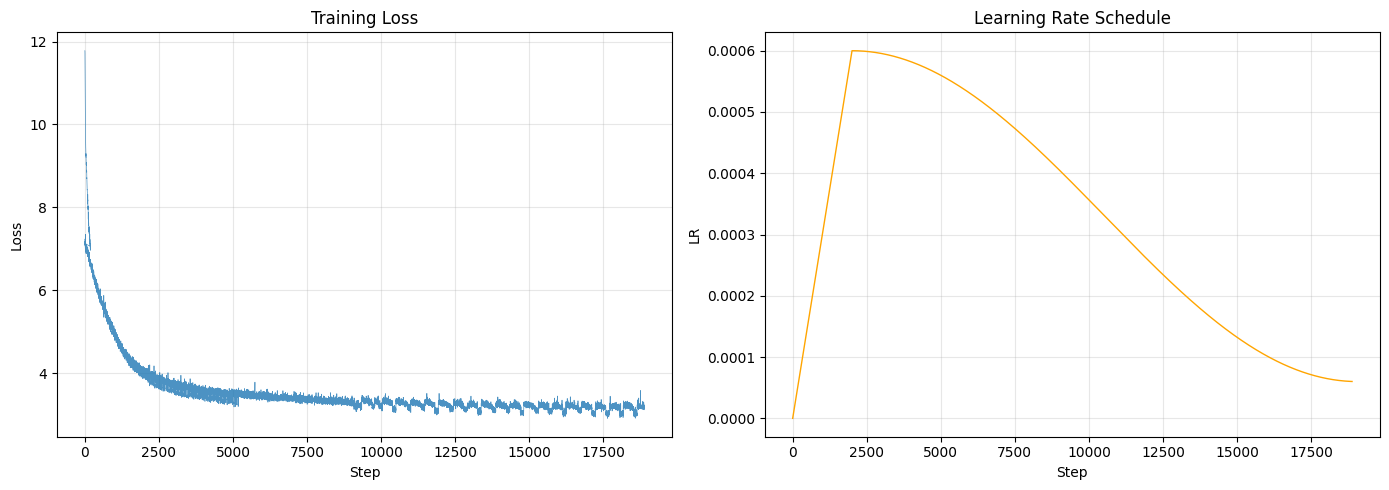

In [ ]:
import matplotlib.pyplot as plt

steps_  = [h["step"] for h in loss_history]
losses_ = [h["loss"] for h in loss_history]
lrs_    = [h["lr"]   for h in loss_history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(steps_, losses_, lw=0.5, alpha=0.8)
ax1.set(xlabel="Step", ylabel="Loss", title="Training Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(steps_, lrs_, lw=1, color="orange")
ax2.set(xlabel="Step", ylabel="LR", title="Learning Rate Schedule")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "curves.png"), dpi=150)
plt.show()

## HellaSwag Evaluation

**AD#18: HellaSwag** — common-sense sentence completion (4-choice).

| Model | HellaSwag |
|-------|-----------|
| Random | 25.0% |
| GPT-2 124M (OpenAI) | 29.4% |
| GPT-2 124M (Karpathy, 10B tokens) | 29.9% |
| Our model | 34% |

In [ ]:
@torch.no_grad()
def eval_hellaswag(model, n=200):
    # AD#18: HellaSwag evaluation
    model.eval()
    ds = load_dataset("Rowan/hellaswag", split="validation")
    correct, total = 0, 0

    for i, ex in enumerate(ds):
        if i >= n:
            break
        ctx = ex["ctx"]
        endings = ex["endings"]
        label = int(ex["label"])

        scores = []
        for ending in endings:
            text = ctx + " " + ending
            toks = enc.encode(text)
            if len(toks) > model_config.block_size:
                toks = toks[:model_config.block_size]

            x = torch.tensor([toks[:-1]], dtype=torch.long, device="cuda")
            y = torch.tensor([toks[1:]],  dtype=torch.long, device="cuda")

            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits, _ = model(x)

            log_p = F.log_softmax(logits, dim=-1)

            # Score only completion tokens (after context)
            ctx_len = max(len(enc.encode(ctx + " ")) - 1, 0)
            ctx_len = min(ctx_len, x.shape[1] - 1)

            comp_lp = [log_p[0, j, y[0, j]].item()
                       for j in range(ctx_len, x.shape[1])]
            scores.append(sum(comp_lp) / max(len(comp_lp), 1))

        if scores.index(max(scores)) == label:
            correct += 1
        total += 1

        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{n} | acc {correct/total:.3f}")

    acc = correct / total
    model.train()
    return acc


print("Evaluating on HellaSwag...")
acc = eval_hellaswag(model, n=200)
print(f"\nHellaSwag: {acc:.3f} ({acc*100:.1f}%)")
print(f"Random: 25.0% | GPT-2: 29.4%")

Evaluating on HellaSwag...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/24.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/6.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/6.32M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/39905 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10042 [00:00<?, ? examples/s]

  50/200 | acc 0.380
  100/200 | acc 0.330
  150/200 | acc 0.340
  200/200 | acc 0.340

HellaSwag: 0.340 (34.0%)
Random: 25.0% | GPT-2: 29.4%


## Text Generation

In [ ]:
@torch.no_grad()
def generate(model, prompt, max_tokens=200, temperature=0.8, top_k=50):
    model.eval()
    tokens = torch.tensor([enc.encode(prompt)], dtype=torch.long, device="cuda")

    for _ in range(max_tokens):
        idx = tokens[:, -model_config.block_size:]
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            logits, _ = model(idx)
        logits = logits[:, -1, :] / temperature

        if top_k > 0:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float("-inf")

        probs = F.softmax(logits, dim=-1)   # AD#5
        tok = torch.multinomial(probs, 1)
        tokens = torch.cat([tokens, tok], dim=1)
        if tok.item() == EOT:
            break

    model.train()
    return enc.decode(tokens[0].tolist())


for p in ["The meaning of life is",
          "In a distant galaxy, scientists discovered",
          "The best way to learn programming is"]:
    print(f"\n{'='*60}")
    print(f"PROMPT: {p}")
    print("=" * 60)
    print(generate(model, p))


PROMPT: The meaning of life is
The meaning of life is as simple as a name. This is the true essence of the person, the essence of the person, the essence of the world. He or she knows the meaning and the meaning of life. If we look at the lives of all the humans, we get the meaning of life. The meaning of life comes from the word for life and the meaning of life comes from the word to live. The meaning of life is always a spiritual truth that is not based on any material object.
What is the meaning of life? We ask ourselves, What is the meaning of life?
The meaning of life comes from the word to live. This is the true essence of the person, the essence of the world. If we look at life, what is the meaning of life?
The meaning of life is a spiritual truth that is not based on anything material or material. It is often a spiritual truth that is based on spiritual insight. When we examine life, we find that we are not living

PROMPT: In a distant galaxy, scientists discovered
In a distan

## Next: Full 10B Token Run

```python
train_config.max_tokens = 10_000_000_000  # 10B tokens
```

Then re-run the training cell. Checkpoints resume automatically.

Expected: ~5-6 hours on a single H100


In [ ]:
train_config.max_tokens = 10_000_000_000  # 10B tokens